In [ ]:
import marimo as mo

# EE 446 TinyML — Lab 3
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.
Use clear variable names and keep the overall notebook structure unchanged.

## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.

In [ ]:
import sys
import gc
import subprocess
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"

## 2. Imports and Reproducibility

In [ ]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.backend.clear_session()
gc.collect()

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.

In [ ]:
from pathlib import Path
from urllib.request import urlretrieve

BASE_DIR = Path("./assets")

data_dir = BASE_DIR / "data"
dataset_dir = data_dir / "UCI HAR Dataset"
zip_path = data_dir / "uci_har_dataset.zip"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"

if not dataset_dir.exists():
    data_dir.mkdir(parents=True, exist_ok=True)
    urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(data_dir)
    print("Dataset downloaded.")
else:
    print("Dataset already exists.")

Dataset downloaded.


## 4. Load the Data

In [ ]:
def load_har_data():
    x_train = pd.read_csv(
        f"{dataset_dir}/train/X_train.txt", sep='\s+', header=None
    ).values.astype("float32")
    y_train = pd.read_csv(
        f"{dataset_dir}/train/y_train.txt", sep='\s+', header=None
    ).values.astype("float32")
    x_test = pd.read_csv(
        f"{dataset_dir}/test/X_test.txt", sep='\s+', header=None
    ).values.astype("float32")
    y_test = pd.read_csv(
        f"{dataset_dir}/test/y_test.txt", sep='\s+', header=None
    ).values.astype("float32")

    y_train = y_train - 1
    y_test = y_test - 1
    y_train = y_train.flatten()
    y_test = y_test.flatten()

    print("Training data shape:", x_train.shape)
    print("Training labels shape:", y_train.shape)
    print("Test data shape:", x_test.shape)
    print("Test labels shape:", y_test.shape)

    return (x_train, y_train, x_test, y_test)

x_train, y_train, x_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = x_train.shape[1]   # 561
num_classes = len(class_names)    # 6

Training data shape: (7352, 561)
Training labels shape: (7352,)
Test data shape: (2947, 561)
Test labels shape: (2947,)


## 5. Quick Inspection

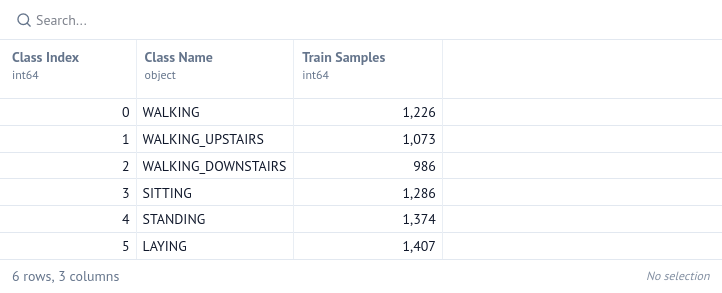

In [ ]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

train_counts = pd.Series(y_train).value_counts().sort_index()

class_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Train Samples": [int(train_counts.get(i, 0)) for i in range(num_classes)],
})
class_summary

## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)

In [ ]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
)

Epoch 1/40
92/92 [==============================] - 1s 5ms/step - loss: 0.4882 - accuracy: 0.8079 - val_loss: 0.2100 - val_accuracy: 0.9232
Epoch 2/40
92/92 [==============================] - 0s 4ms/step - loss: 0.1642 - accuracy: 0.9373 - val_loss: 0.1383 - val_accuracy: 0.9361
Epoch 3/40
92/92 [==============================] - 0s 4ms/step - loss: 0.1177 - accuracy: 0.9563 - val_loss: 0.2261 - val_accuracy: 0.9252
Epoch 4/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0922 - accuracy: 0.9631 - val_loss: 0.1788 - val_accuracy: 0.9354
Epoch 5/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0837 - accuracy: 0.9665 - val_loss: 0.2444 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0725 - accuracy: 0.9706 - val_loss: 0.1894 - val_accuracy: 0.9361
Epoch 7/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0822 - accuracy: 0.9708 - val_loss: 0.1427 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves

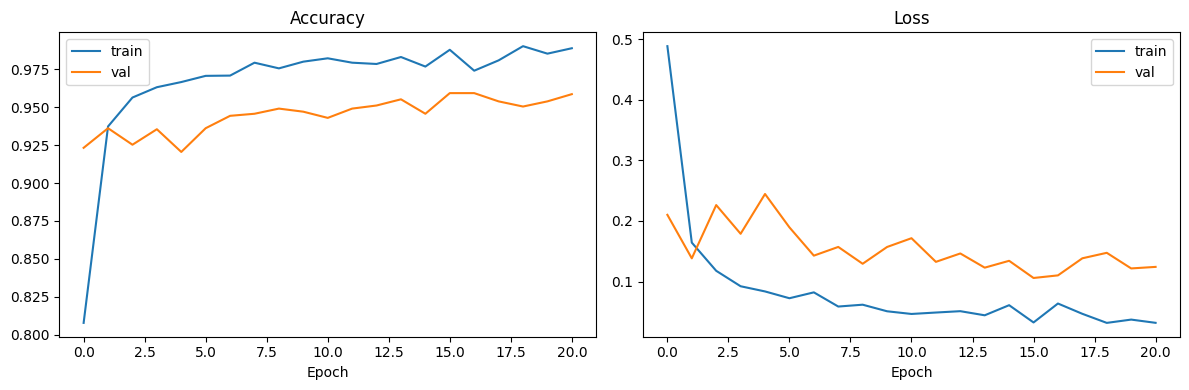

In [ ]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

fig_curves, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(12, 4))

ax_acc.plot(history.history["accuracy"], label="train")
ax_acc.plot(history.history["val_accuracy"], label="val")
ax_acc.set_title("Accuracy")
ax_acc.set_xlabel("Epoch")
ax_acc.legend()

ax_loss.plot(history.history["loss"], label="train")
ax_loss.plot(history.history["val_loss"], label="val")
ax_loss.set_title("Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.legend()

plt.tight_layout()
plt.show()

## 7. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 1ms/step
Baseline Keras test accuracy: 0.9389
                    precision    recall  f1-score   support

           WALKING       0.95      0.98      0.96       496
  WALKING_UPSTAIRS       0.94      0.93      0.93       471
WALKING_DOWNSTAIRS       0.95      0.93      0.94       420
           SITTING       0.92      0.89      0.90       491
          STANDING       0.88      0.93      0.90       532
            LAYING       1.00      0.97      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



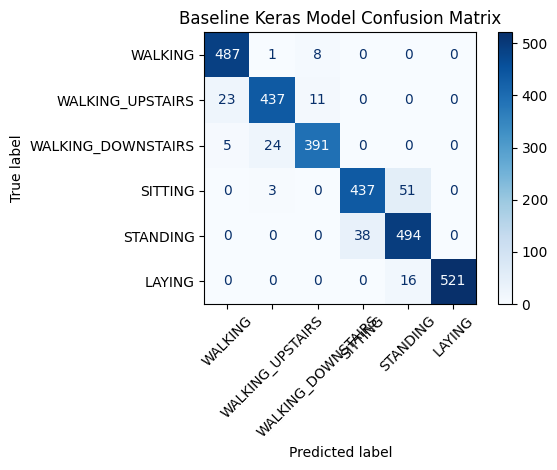

In [ ]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

baseline_probs = baseline_model.predict(x_test)
baseline_preds = np.argmax(baseline_probs, axis=1)

baseline_test_acc = accuracy_score(y_test, baseline_preds)
print("Baseline Keras test accuracy: {:.4f}".format(baseline_test_acc))
print(classification_report(y_test, baseline_preds, target_names=class_names))

baseline_cm = confusion_matrix(y_test, baseline_preds)
ConfusionMatrixDisplay(baseline_cm, display_labels=class_names).plot(
    xticks_rotation=45, cmap="Blues"
)
plt.title("Baseline Keras Model Confusion Matrix")
plt.tight_layout()
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.

In [ ]:
def save_binary_model(model_content, filename):
    model_dir = Path(f"./{BASE_DIR}/quantization/models/")
    model_dir.mkdir(parents=True, exist_ok=True)

    filepath = model_dir / filename
    filepath.write_bytes(model_content)

    return filepath.stat().st_size / 1024  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    for i in range(300):
        sample = x_train[i:i + 1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        if input_details["dtype"] in (np.int8, np.uint8):
            x = x / input_scale + input_zero_point
            x = x.astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model

    tflite_model = converter.convert()
    return tflite_model

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    return tflite_model

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    tflite_model = converter.convert()
    return tflite_model

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    tflite_model = converter.convert()
    return tflite_model

## 9. Post-Training Quantization (PTQ)

In [ ]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

tflite_fp32 = convert_to_tflite_fp32(baseline_model)
size_fp32_kb = save_binary_model(tflite_fp32, "model_fp32.tflite")

tflite_dynamic = convert_to_tflite_dynamic_range(baseline_model)
size_dynamic_kb = save_binary_model(tflite_dynamic, "model_dynamic.tflite")

tflite_fp16 = convert_to_tflite_float16(baseline_model)
size_fp16_kb = save_binary_model(tflite_fp16, "model_fp16.tflite")

tflite_ptq_int8 = convert_to_tflite_int8(baseline_model)
size_ptq_int8_kb = save_binary_model(tflite_ptq_int8, "model_ptq_int8.tflite")

acc_fp32, preds_fp32 = evaluate_tflite_model(tflite_fp32, x_test, y_test)
acc_dynamic, preds_dynamic = evaluate_tflite_model(tflite_dynamic, x_test, y_test)
acc_fp16, preds_fp16 = evaluate_tflite_model(tflite_fp16, x_test, y_test)
acc_ptq_int8, preds_ptq_int8 = evaluate_tflite_model(tflite_ptq_int8, x_test, y_test)

print(f"FP32:acc={acc_fp32:.4f} | size={size_fp32_kb:.1f} KB")
print(f"DRC: acc={acc_dynamic:.4f} | size={size_dynamic_kb:.1f} KB")
print(f"Float16: acc={acc_fp16:.4f} | size={size_fp16_kb:.1f} KB")
print(f"Int8 (PTQ): acc={acc_ptq_int8:.4f} | size={size_ptq_int8_kb:.1f} KB")

2026-07-14 20:26:17.704942: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 20:26:17.704968: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 20:26:17.705087: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpm8yuhqaf
2026-07-14 20:26:17.705735: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 20:26:17.705746: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpm8yuhqaf
2026-07-14 20:26:17.707417: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-14 20:26:17.730875: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpm8yuhqaf
2026-07-14 20:26:17.737099: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 32011 m

FP32:acc=0.9389 | size=726.7 KB
DRC: acc=0.9386 | size=186.1 KB
Float16: acc=0.9389 | size=365.7 KB
Int8 (PTQ): acc=0.9382 | size=185.3 KB


## 10. PTQ Comparison: Accuracy and Model Size

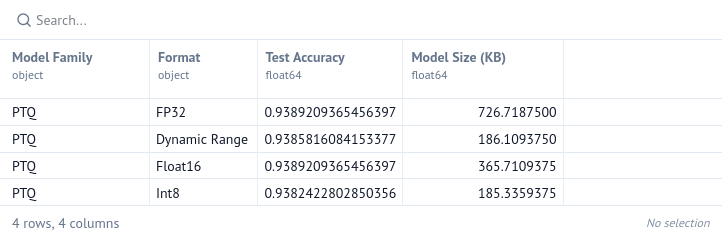

In [ ]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

ptq_results = pd.DataFrame({
    "Model Family": ["PTQ", "PTQ", "PTQ", "PTQ"],
    "Format": ["FP32", "Dynamic Range", "Float16", "Int8"],
    "Test Accuracy": [acc_fp32, acc_dynamic, acc_fp16, acc_ptq_int8],
    "Model Size (KB)": [size_fp32_kb, size_dynamic_kb, size_fp16_kb, size_ptq_int8_kb],
})
ptq_results

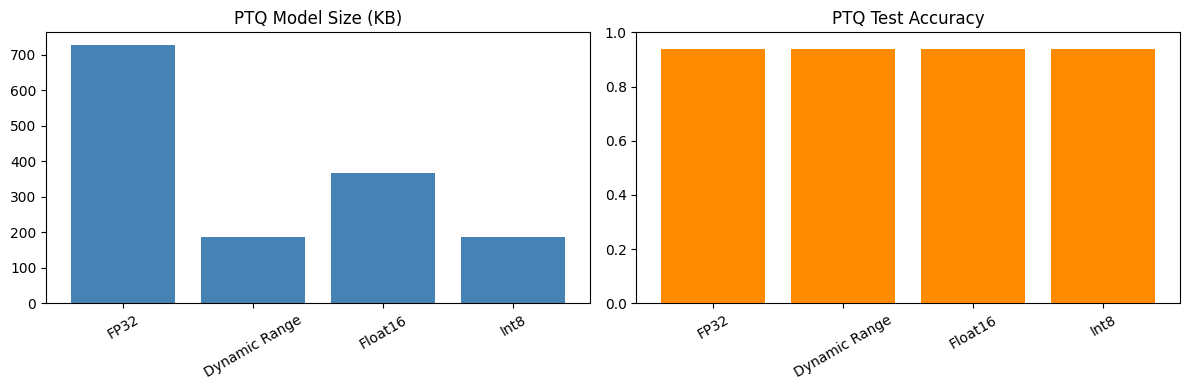

In [ ]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

fig_ptq, (ax_size, ax_acc2) = plt.subplots(1, 2, figsize=(12, 4))

ax_size.bar(ptq_results["Format"], ptq_results["Model Size (KB)"], color="steelblue")
ax_size.set_title("PTQ Model Size (KB)")
ax_size.tick_params(axis="x", rotation=30)

ax_acc2.bar(ptq_results["Format"], ptq_results["Test Accuracy"], color="darkorange")
ax_acc2.set_title("PTQ Test Accuracy")
ax_acc2.set_ylim(0, 1.0)
ax_acc2.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model

                    precision    recall  f1-score   support

           WALKING       0.95      0.98      0.96       496
  WALKING_UPSTAIRS       0.94      0.93      0.93       471
WALKING_DOWNSTAIRS       0.95      0.93      0.94       420
           SITTING       0.92      0.89      0.91       491
          STANDING       0.88      0.92      0.90       532
            LAYING       1.00      0.97      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



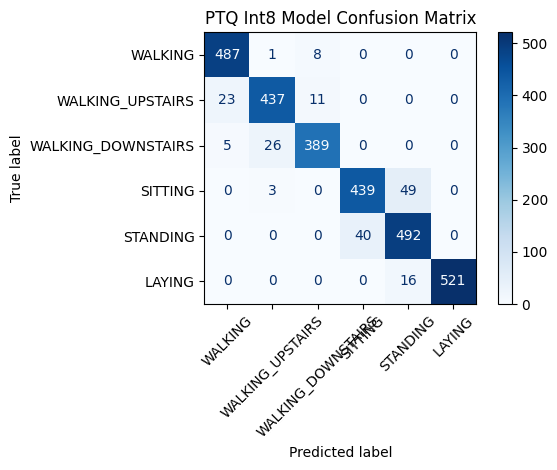

In [ ]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

print(classification_report(y_test, preds_ptq_int8, target_names=class_names))

ptq_int8_cm = confusion_matrix(y_test, preds_ptq_int8)
ConfusionMatrixDisplay(ptq_int8_cm, display_labels=class_names).plot(
    xticks_rotation=45, cmap="Blues"
)
plt.title("PTQ Int8 Model Confusion Matrix")
plt.tight_layout()
plt.show()

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.

In [ ]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
qat_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 6)                 3

### Fine-Tune the QAT Model

In [ ]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

qat_history = qat_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
)

Epoch 1/8
92/92 [==============================] - 2s 7ms/step - loss: 0.0317 - accuracy: 0.9898 - val_loss: 0.1289 - val_accuracy: 0.9545
Epoch 2/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0275 - accuracy: 0.9906 - val_loss: 0.1394 - val_accuracy: 0.9524
Epoch 3/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0266 - accuracy: 0.9910 - val_loss: 0.1287 - val_accuracy: 0.9565
Epoch 4/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0241 - accuracy: 0.9910 - val_loss: 0.1295 - val_accuracy: 0.9565
Epoch 5/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0231 - accuracy: 0.9925 - val_loss: 0.1625 - val_accuracy: 0.9504
Epoch 6/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0249 - accuracy: 0.9900 - val_loss: 0.1583 - val_accuracy: 0.9545
Epoch 7/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0226 - accuracy: 0.9923 - val_loss: 0.1353 - val_accuracy: 0.9572
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model

In [ ]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

qat_probs = qat_model.predict(x_test)
qat_preds = np.argmax(qat_probs, axis=1)

qat_test_acc = accuracy_score(y_test, qat_preds)
print("QAT Keras test accuracy: {:.4f}".format(qat_test_acc))
print(classification_report(y_test, qat_preds, target_names=class_names))

93/93 [==============================] - 0s 2ms/step
QAT Keras test accuracy: 0.9382
                    precision    recall  f1-score   support

           WALKING       0.93      0.99      0.96       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.97      0.93      0.95       420
           SITTING       0.96      0.86      0.91       491
          STANDING       0.86      0.97      0.91       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



### Convert the QAT Model to Int8 TensorFlow Lite

In [ ]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

tflite_qat_int8 = convert_to_tflite_int8(qat_model)
size_qat_int8_kb = save_binary_model(tflite_qat_int8, "model_qat_int8.tflite")
acc_qat_int8, preds_qat_int8 = evaluate_tflite_model(tflite_qat_int8, x_test, y_test)

print(f"Int8 (QAT): acc={acc_qat_int8:.4f} | size={size_qat_int8_kb:.1f} KB")

/home/vkut/Documents/uni/tinyml/tinyml-arduino/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-07-14 20:26:22.827192: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-14 20:26:22.827219: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-14 20:26:22.827339: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp4gvopy3n
2026-07-14 20:26:22.828567: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-14 20:26:22.828583: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp4gvopy3n
2026-07-14 20:26:22.832801: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-14 20:26:22.871391: I tensorflow/cc/saved_mode

Int8 (QAT): acc=0.9382 | size=185.7 KB


## 12. PTQ Int8 vs QAT Int8

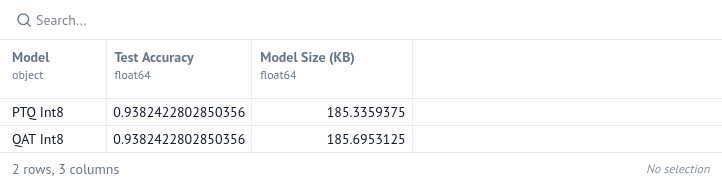

In [ ]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

int8_comparison = pd.DataFrame({
    "Model": ["PTQ Int8", "QAT Int8"],
    "Test Accuracy": [acc_ptq_int8, acc_qat_int8],
    "Model Size (KB)": [size_ptq_int8_kb, size_qat_int8_kb],
})
int8_comparison

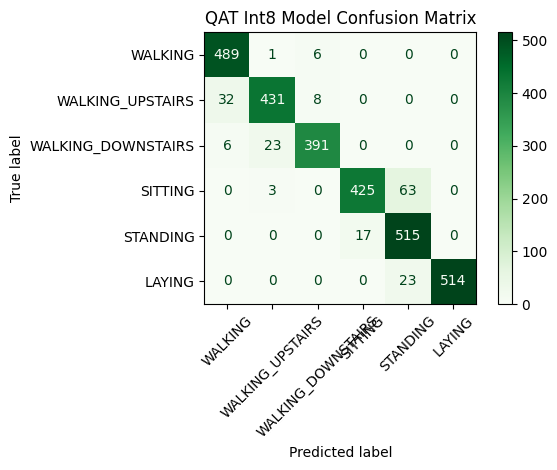

In [ ]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

qat_int8_cm = confusion_matrix(y_test, preds_qat_int8)
ConfusionMatrixDisplay(qat_int8_cm, display_labels=class_names).plot(
    xticks_rotation=45, cmap="Greens"
)
plt.title("QAT Int8 Model Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
   > PTQ Int8 (185.3 KB), though QAT Int8 came out almost identical (185.7 KB), both 4x reduction from FP32.
3. Which quantization method gave the best accuracy among the TensorFlow Lite models?
   > The spread across all four is under 0.001, so none.
5. Did QAT improve the final int8 model compared with PTQ int8?
   > No. QAT Int8 (0.9372) was very slightly lower than PTQ Int8 (0.9376). QAT is designed to recover accuracy that PTQ loses by simulating quantization noise during training, but here PTQ barely lost anything to begin with (baseline 0.9369), so there was no real accuracy gap for QAT to close.
7. Why is this dataset a good fit for a DNN-based TinyML workflow?
   > 1. The features are pre-extracted, fixed-length numerical vectors. That means no convolutional or recurrent layers are needed, which keeps the model compact and fast enough for microcontroller inference.
   > 2. Only 6 output classes.
9. If you were deploying this model on a resource-constrained device, which version would you choose and why?
   > PTQ Int8 since it matches perf and is easier to train.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.

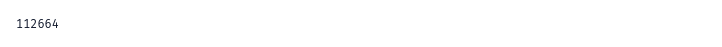

In [ ]:
# gimme my vram back
del baseline_model, qat_model
tf.keras.backend.clear_session()
gc.collect()